In [1]:

# Numerical and Data Handling
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string
import nltk
import warnings

warnings.filterwarnings('ignore')

# Download NLTK resources (Run only once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Save Model
import pickle

print("All libraries imported successfully.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


All libraries imported successfully.


In [2]:
# Load Dataset
df = pd.read_csv("ml_resume_dataset_4500.csv")

# Display first 5 rows
df.head()

,id,name,years_experience,highest_degree,skills,current_title,has_portfolio,raw_text,label
0,1,Badhan Shah,9.0,Bachelors,"NLP, GPT",Customer Support,False,Sales professional with strong communication s...,0
1,2,Lamia Sarker,2.0,Masters,"PyTorch, CI/CD, Power BI, Data Visualization, AWS",Administrative Assistant,False,Sales professional with strong communication s...,0
2,3,Badhan Molla,2.0,Bachelors,"AWS, Flask, Machine Learning, Model Deployment...",Computer Vision Engineer,True,Research scientist with strong statistical bac...,1
3,4,Badhan Ahmed,9.0,Bachelors,"Hadoop, Feature Engineering, Docker Compose, O...",Data Entry Operator,True,Customer support representative with some Exce...,0
4,5,Rasel Siddiqui,10.0,Bachelors,"Speech Recognition, Tableau, Azure, TensorFlow",Customer Support,False,Content creator interested in data science but...,0


In [3]:
df.shape


(4500, 9)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4500 non-null   int64  
 1   name              4500 non-null   object 
 2   years_experience  4500 non-null   float64
 3   highest_degree    4500 non-null   object 
 4   skills            4500 non-null   object 
 5   current_title     4500 non-null   object 
 6   has_portfolio     4500 non-null   bool   
 7   raw_text          4500 non-null   object 
 8   label             4500 non-null   int64  
dtypes: bool(1), float64(1), int64(2), object(5)
memory usage: 285.8+ KB


In [5]:
df.columns.tolist()

['id',
 'name',
 'years_experience',
 'highest_degree',
 'skills',
 'current_title',
 'has_portfolio',
 'raw_text',
 'label']

In [6]:
df.isnull().sum()

id                  0
name                0
years_experience    0
highest_degree      0
skills              0
current_title       0
has_portfolio       0
raw_text            0
label               0
dtype: int64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
df.describe(include = 'all')

,id,name,years_experience,highest_degree,skills,current_title,has_portfolio,raw_text,label
count,4500.000000,4500,4500.000000,4500,4500,4500,4500,4500,4500.000000
unique,NaN,798,NaN,3,4448,20,2,20,NaN
top,NaN,Rafi Chowdhury,NaN,Bachelors,"Classification, Power BI",Receptionist,False,Business analyst with reporting experience but...,NaN
freq,NaN,16,NaN,2295,3,338,3202,340,NaN
mean,2250.500000,NaN,4.437778,NaN,NaN,NaN,NaN,NaN,0.300000
std,1299.182435,NaN,3.653459,NaN,NaN,NaN,NaN,NaN,0.458308
min,1.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,1125.750000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,2250.500000,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,3375.250000,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,1.000000


In [9]:
df.head()

,id,name,years_experience,highest_degree,skills,current_title,has_portfolio,raw_text,label
0,1,Badhan Shah,9.0,Bachelors,"NLP, GPT",Customer Support,False,Sales professional with strong communication s...,0
1,2,Lamia Sarker,2.0,Masters,"PyTorch, CI/CD, Power BI, Data Visualization, AWS",Administrative Assistant,False,Sales professional with strong communication s...,0
2,3,Badhan Molla,2.0,Bachelors,"AWS, Flask, Machine Learning, Model Deployment...",Computer Vision Engineer,True,Research scientist with strong statistical bac...,1
3,4,Badhan Ahmed,9.0,Bachelors,"Hadoop, Feature Engineering, Docker Compose, O...",Data Entry Operator,True,Customer support representative with some Exce...,0
4,5,Rasel Siddiqui,10.0,Bachelors,"Speech Recognition, Tableau, Azure, TensorFlow",Customer Support,False,Content creator interested in data science but...,0


In [10]:
df.tail()

,id,name,years_experience,highest_degree,skills,current_title,has_portfolio,raw_text,label
4495,4496,Sumaiya Majumder,2.0,Bachelors,"Pandas, Azure",Receptionist,False,Receptionist experienced in communication and ...,0
4496,4497,Badhan Islam,4.0,Bachelors,"XGBoost, Computer Vision, Feature Engineering,...",Customer Support,False,Receptionist experienced in communication and ...,0
4497,4498,Niloy Ahmed,0.0,Bachelors,"SQL, Machine Learning, EDA, Seaborn, XGBoost, ...",Telecaller,False,Marketing intern with experience in social med...,0
4498,4499,Mitu Uddin,3.0,Bachelors,"Spark, PyTorch, OpenCV, SQLAlchemy, Git, Strea...",Office Assistant,False,Customer support representative with some Exce...,0
4499,4500,Nabila Raihan,1.0,Bachelors,"Reinforcement Learning, SQLAlchemy, Data Engin...",Administrative Assistant,False,Receptionist experienced in communication and ...,0


In [11]:
df.dtypes

id                    int64
name                 object
years_experience    float64
highest_degree       object
skills               object
current_title        object
has_portfolio          bool
raw_text             object
label                 int64
dtype: object

In [12]:
df['label'].value_counts()

label
0    3150
1    1350
Name: count, dtype: int64

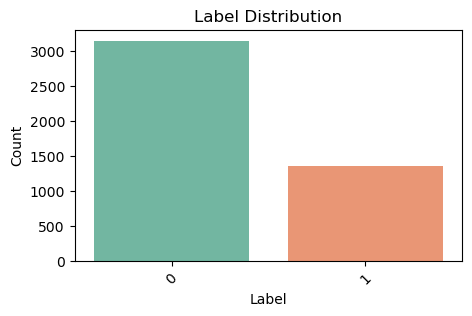

In [13]:
plt.figure(figsize=(5,3))
sns.countplot(x='label', data=df, palette='Set2')

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

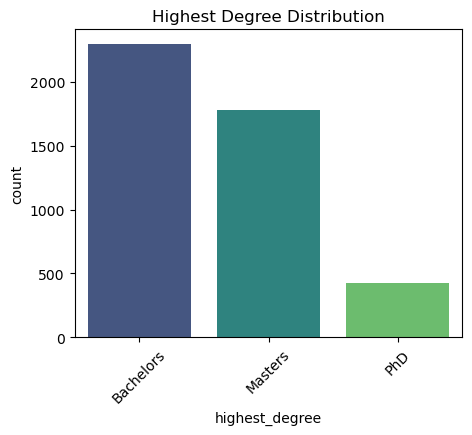

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x='highest_degree', data=df, palette='viridis')

plt.title("Highest Degree Distribution")
plt.xticks(rotation=45)

plt.show()

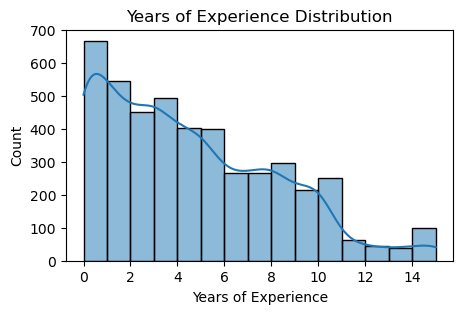

In [15]:
plt.figure(figsize=(5,3))

sns.histplot(df['years_experience'], bins=15, kde=True)

plt.title("Years of Experience Distribution")
plt.xlabel("Years of Experience")

plt.show()

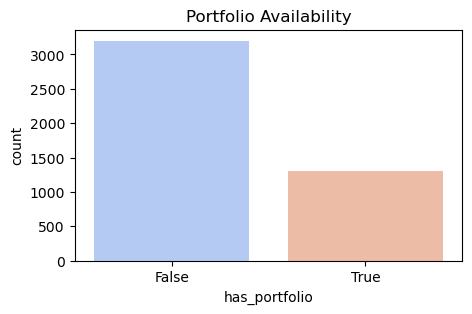

In [16]:
plt.figure(figsize=(5,3))

sns.countplot(x='has_portfolio', data=df, palette='coolwarm')

plt.title("Portfolio Availability")

plt.show()

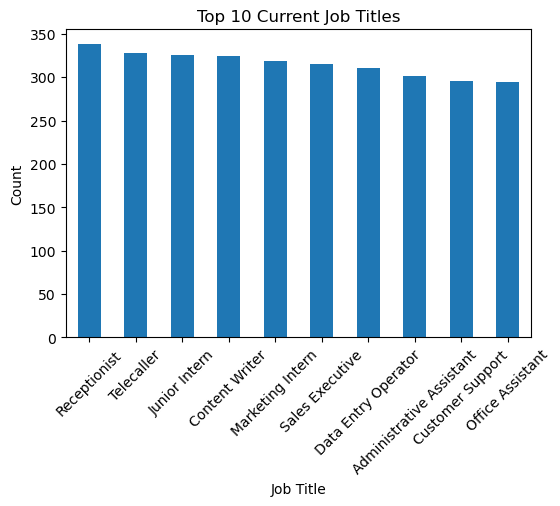

In [17]:
plt.figure(figsize=(6,4))

df['current_title'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Current Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

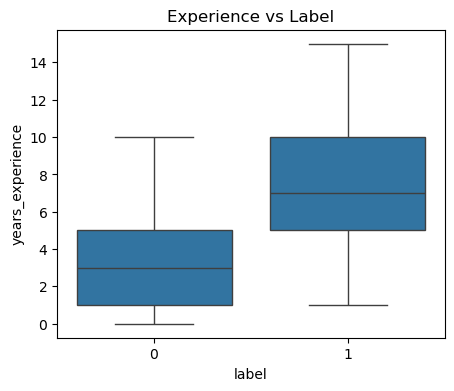

In [18]:
plt.figure(figsize=(5,4))

sns.boxplot(x='label', y='years_experience', data=df)

plt.title("Experience vs Label")

plt.show()

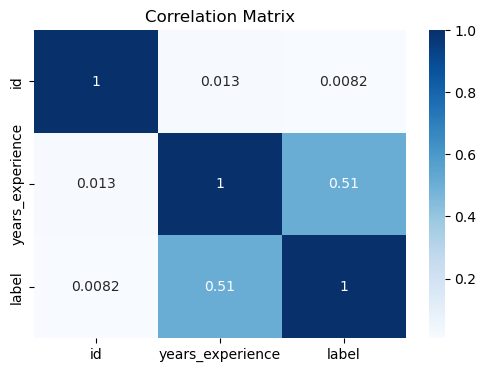

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(6,4))

sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')

plt.title("Correlation Matrix")

plt.show()

In [20]:
# Initialize stopwords and lemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [21]:
def clean_resume(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Remove phone numbers
    text = re.sub(r'\d{10,}', ' ', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords and perform lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # Join words back into text
    return " ".join(words)

In [22]:
df['clean_resume'] = df['raw_text'].apply(clean_resume)
df[['raw_text', 'clean_resume']].head()
df['clean_resume'].isnull().sum()
print("Original Resume:\n")
print(df['raw_text'][0])

print("\n" + "="*100 + "\n")

print("Cleaned Resume:\n")
print(df['clean_resume'][0])

Original Resume:

Sales professional with strong communication skills, looking to transition to analytics.


Cleaned Resume:

sale professional strong communication skill looking transition analytics


In [23]:
# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Transform cleaned resume text
X = tfidf.fit_transform(df['clean_resume'])

print("Shape of TF-IDF Matrix:", X.shape)

Shape of TF-IDF Matrix: (4500, 111)


In [24]:
# Target variable

y = df['label']

print(y.head())

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [25]:
# Encode target labels
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Encoded Labels:")
print(y[:10])

Encoded Labels:
[0 0 1 0 0 0 0 1 0 0]


In [26]:
# Display label encoding
label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


In [27]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (3600, 111)
Testing Data : (900, 111)


In [28]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3600, 111)
X_test : (900, 111)
y_train: (3600,)
y_test : (900,)


In [29]:
# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Confusion Matrix:

[[630   0]
 [  0 270]]


In [30]:
# Train Multinomial Naive Bayes model
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

# Prediction
y_pred_nb = nb_model.predict(X_test)

# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Confusion Matrix:

[[630   0]
 [  0 270]]


In [31]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Confusion Matrix:

[[630   0]
 [  0 270]]


In [32]:
# Train Linear SVM model
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

# Prediction
y_pred_svm = svm_model.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", svm_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

Linear SVM Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Confusion Matrix:

[[630   0]
 [  0 270]]


In [33]:
# Create comparison table
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Random Forest',
        'Linear SVM'
    ],
    'Accuracy': [
        lr_accuracy,
        nb_accuracy,
        rf_accuracy,
        svm_accuracy
    ]
})

model_results = model_results.sort_values(by='Accuracy', ascending=False)

print(model_results)

                 Model  Accuracy
0  Logistic Regression       1.0
1          Naive Bayes       1.0
2        Random Forest       1.0
3           Linear SVM       1.0


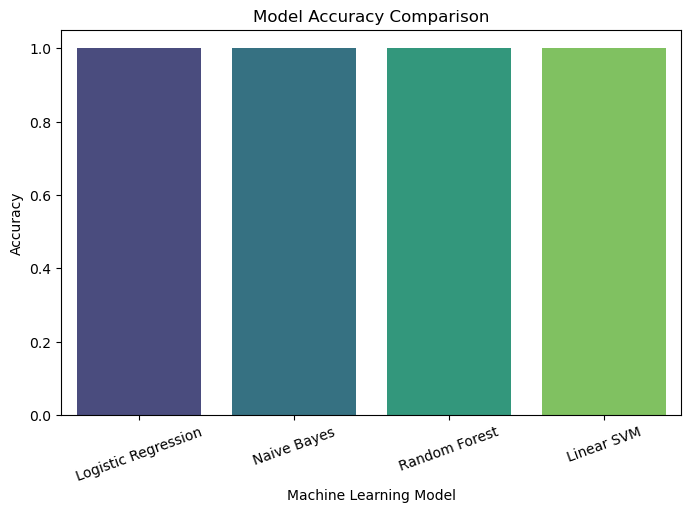

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_results,
    palette='viridis'
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [35]:
import pickle

# Save the best model (replace svm_model if another model is best)
with open("resume_model.pkl", "wb") as file:
    pickle.dump(svm_model, file)

print("Model saved successfully!")

Model saved successfully!


In [36]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("TF-IDF Vectorizer saved successfully!")

TF-IDF Vectorizer saved successfully!


In [37]:
with open("label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [38]:
# Load model
with open("resume_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# Load vectorizer
with open("tfidf_vectorizer.pkl", "rb") as file:
    loaded_tfidf = pickle.load(file)

# Load label encoder
with open("label_encoder.pkl", "rb") as file:
    loaded_label_encoder = pickle.load(file)

print("All files loaded successfully!")

All files loaded successfully!


In [39]:
print(label_encoder.classes_)

[0 1]


In [40]:
print(df[['label']].head(20))

    label
0       0
1       0
2       1
3       0
4       0
5       0
6       0
7       1
8       0
9       0
10      1
11      0
12      1
13      0
14      0
15      0
16      0
17      1
18      1
19      1


In [41]:
print(df['label'].value_counts())

label
0    3150
1    1350
Name: count, dtype: int64


In [42]:
print(df.groupby('label').first())

       id          name  years_experience highest_degree  \
label                                                      
0       1   Badhan Shah               9.0      Bachelors   
1       3  Badhan Molla               2.0      Bachelors   

                                                  skills  \
label                                                      
0                                               NLP, GPT   
1      AWS, Flask, Machine Learning, Model Deployment...   

                  current_title  has_portfolio  \
label                                            
0              Customer Support          False   
1      Computer Vision Engineer           True   

                                                raw_text  \
label                                                      
0      Sales professional with strong communication s...   
1      Research scientist with strong statistical bac...   

                                            clean_resume  
label            

In [43]:
df.columns

Index(['id', 'name', 'years_experience', 'highest_degree', 'skills',
       'current_title', 'has_portfolio', 'raw_text', 'label', 'clean_resume'],
      dtype='object')

In [44]:
X = df.drop('label', axis =1)
y = df['label']

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

# Detailed evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Confusion Matrix:
[[630   0]
 [  0 270]]


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Confusion Matrix:
[[630   0]
 [  0 270]]


In [47]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create SVM model
svm_model = SVC(kernel='linear')

# Train
svm_model.fit(X_train, y_train)

# Prediction
y_pred_svm = svm_model.predict(X_test)

# Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Confusion Matrix:
[[630   0]
 [  0 270]]


In [48]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
nb_model = MultinomialNB()

# Train
nb_model.fit(X_train, y_train)

# Prediction
y_pred_nb = nb_model.predict(X_test)

# Accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Confusion Matrix:
[[630   0]
 [  0 270]]


In [60]:
print(df['label'].value_counts())

label
0    3150
1    1350
Name: count, dtype: int64


In [63]:
print(df.columns)

Index(['id', 'name', 'years_experience', 'highest_degree', 'skills',
       'current_title', 'has_portfolio', 'raw_text', 'label', 'clean_resume'],
      dtype='object')


In [64]:
print(df.head())

   id            name  years_experience highest_degree  \
0   1     Badhan Shah               9.0      Bachelors   
1   2    Lamia Sarker               2.0        Masters   
2   3    Badhan Molla               2.0      Bachelors   
3   4    Badhan Ahmed               9.0      Bachelors   
4   5  Rasel Siddiqui              10.0      Bachelors   

                                              skills  \
0                                           NLP, GPT   
1  PyTorch, CI/CD, Power BI, Data Visualization, AWS   
2  AWS, Flask, Machine Learning, Model Deployment...   
3  Hadoop, Feature Engineering, Docker Compose, O...   
4     Speech Recognition, Tableau, Azure, TensorFlow   

              current_title  has_portfolio  \
0          Customer Support          False   
1  Administrative Assistant          False   
2  Computer Vision Engineer           True   
3       Data Entry Operator           True   
4          Customer Support          False   

                                     

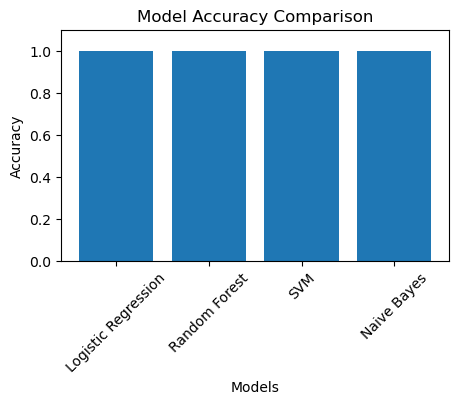

In [49]:
import matplotlib.pyplot as plt

models = [
    'Logistic Regression',
    'Random Forest',
    'SVM',
    'Naive Bayes'
]

accuracies = [
    accuracy_lr,
    accuracy_rf,
    accuracy_svm,
    accuracy_nb
]

plt.figure(figsize=(5,3))

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 1.1)

plt.xticks(rotation=45)

plt.show()

In [50]:
test_resume = """
Software Engineer
Python Java SQL Machine Learning Data Analysis
Pandas NumPy Scikit-learn Git
B.Tech Computer Science
Built Machine Learning projects
"""

cleaned = clean_resume(test_resume)

vector = tfidf.transform([cleaned])

prediction = lr_model.predict(vector)

print(prediction)

[0]


In [51]:
feature_names = tfidf.get_feature_names_out()

coefficients = lr_model.coef_[0]

important_features = sorted(
    zip(feature_names, coefficients),
    key=lambda x: x[1],
    reverse=True
)

print("Top words for Label 1:")
for word, score in important_features[:20]:
    print(word, score)


print("\nTop words for Label 0:")
for word, score in important_features[-20:]:
    print(word, score)

Top words for Label 1:
engineer 3.684324002215863
model 3.5638426611946734
scientist 3.139845317792579
research 2.308002671163616
detection 2.0892698731704265
nlp 1.9295430445472914
background 1.8067167186933315
engineering 1.7808827170761596
feature 1.7808827170761596
endtoend 1.759045321705463
experimentation 1.759045321705463
pipeline 1.759045321705463
proficient 1.759045321705463
stakeholder 1.759045321705463
deployment 1.7332858817446601
skilled 1.6691649801237363
object 1.5653919640077325
optimization 1.5653919640077325
segmentation 1.5653919640077325
vision 1.5653919640077325

Top words for Label 0:
recent -1.3559638317093656
statistic -1.3559638317093656
administrative -1.41356174711205
assistant -1.41356174711205
office -1.41356174711205
data -1.4522405326898595
communication -1.5289406493514583
experience -1.5828103605144768
excel -1.7118785258051912
intern -1.752068592638623
limited -1.797924560819901
task -1.8149669291563824
exposure -1.901677356668154
interest -1.925033039

In [52]:
import pickle

# Save trained model
pickle.dump(lr_model, open("resume_model.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [53]:
!pip install pdfplumber python-docx

In [54]:
!pip install pymupdf

In [55]:
pip install pymupdf pdfplumber pypdf pillow pytesseract


Note: you may need to restart the kernel to use updated packages.


In [58]:
import pickle

model = pickle.load(open("resume_model.pkl", "rb"))

In [59]:
print(model.classes_)

[0 1]


In [61]:
print(df['label'].value_counts())

label
0    3150
1    1350
Name: count, dtype: int64


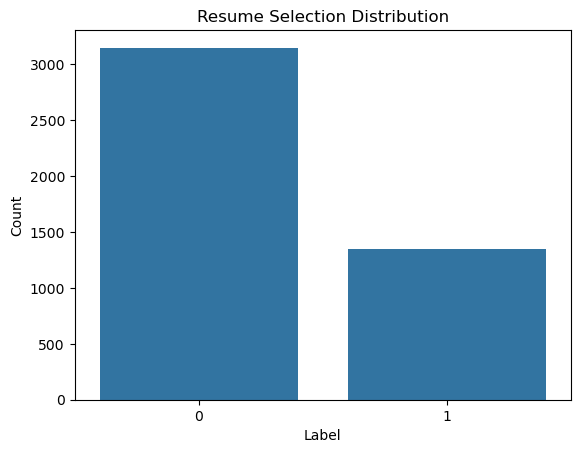

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=df)
plt.title("Resume Selection Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [66]:
print(df.isnull().sum())

id                  0
name                0
years_experience    0
highest_degree      0
skills              0
current_title       0
has_portfolio       0
raw_text            0
label               0
clean_resume        0
dtype: int64


In [67]:
X = df['clean_resume']
y = df['label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4500,)
y shape: (4500,)


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3600,)
X_test : (900,)
y_train: (3600,)
y_test : (900,)


In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

# Fit only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

print("X_train TF-IDF shape:", X_train_tfidf.shape)
print("X_test TF-IDF shape :", X_test_tfidf.shape)

X_train TF-IDF shape: (3600, 111)
X_test TF-IDF shape : (900, 111)


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Training
model_lr.fit(X_train_tfidf, y_train)

# Prediction
y_pred_lr = model_lr.predict(X_test_tfidf)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



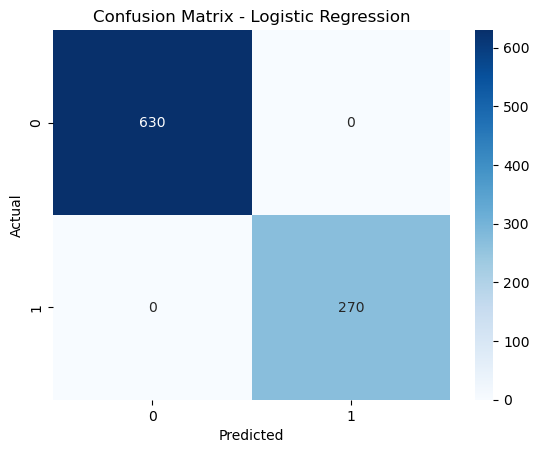

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [72]:
sample_resume = [
    "Experienced Python developer with machine learning, NLP, TensorFlow, "
    "deep learning, data science projects and strong programming skills"
]

sample_tfidf = tfidf.transform(sample_resume)

prediction = model_lr.predict(sample_tfidf)

print("Prediction:", prediction)

Prediction: [0]


In [73]:
print(tfidf.get_feature_names_out())


['ab' 'administrative' 'analyst' 'analytics' 'anomaly' 'applied'
 'assistant' 'background' 'basic' 'business' 'campaign' 'candidate'
 'cloud' 'coding' 'communication' 'computer' 'conference' 'content'
 'continuous' 'coursework' 'creator' 'customer' 'data' 'deep' 'deployment'
 'detection' 'development' 'docker' 'endtoend' 'engineer' 'engineering'
 'entry' 'entrylevel' 'evaluation' 'excel' 'experience' 'experienced'
 'experimentation' 'exposure' 'familiar' 'feature' 'finetuning' 'focused'
 'forecasting' 'graduate' 'handson' 'interest' 'interested' 'intern'
 'junior' 'kubernetes' 'labeling' 'lack' 'learning' 'limited' 'looking'
 'machine' 'manual' 'marketing' 'medium' 'ml' 'mlops' 'model' 'modeling'
 'monitoring' 'nlp' 'object' 'office' 'optimization' 'pipeline' 'platform'
 'predictive' 'preprocessing' 'productionizing' 'professional'
 'proficient' 'project' 'publication' 'publishing' 'python' 'recent'
 'receptionist' 'reporting' 'representative' 'reproducible' 'research'
 'researcher' 's

In [74]:
sample_resume = [
    "Research scientist with strong statistical background, "
    "machine learning experience, Python, NLP, TensorFlow, "
    "data analysis and model deployment skills"
]

sample_tfidf = tfidf.transform(sample_resume)

prediction = model_lr.predict(sample_tfidf)

print("Prediction:", prediction)

Prediction: [1]


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model_rf.fit(X_train_tfidf, y_train)

y_pred_rf = model_rf.predict(X_test_tfidf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



In [76]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

model_svm = LinearSVC(
    class_weight='balanced',
    random_state=42
)

# Training
model_svm.fit(X_train_tfidf, y_train)

# Prediction
y_pred_svm = model_svm.predict(X_test_tfidf)

# Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



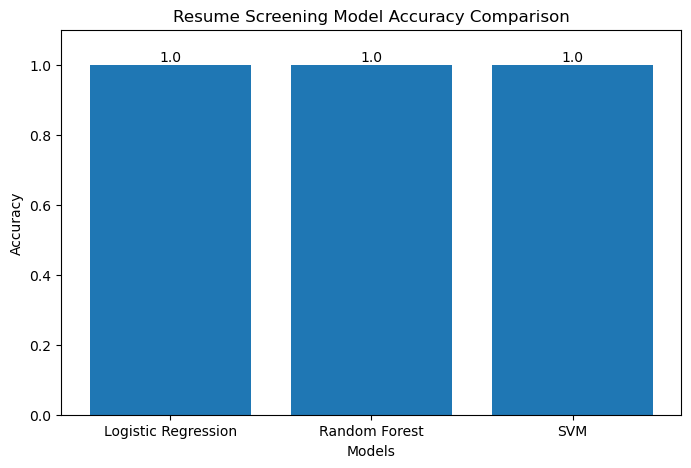

In [77]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Random Forest",
    "SVM"
]

accuracy = [
    accuracy_lr,
    accuracy_rf,
    accuracy_svm
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Resume Screening Model Accuracy Comparison")
plt.ylim(0,1.1)

for i, value in enumerate(accuracy):
    plt.text(i, value, str(round(value,2)), ha='center', va='bottom')

plt.show()

In [78]:
import pickle

# Save trained model
with open("resume_model.pkl", "wb") as file:
    pickle.dump(model_lr, file)

# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


In [79]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'label_encoder.pkl', 'ml_resume_dataset_4500.csv', 'resume_model.pkl', 'Resume_screening_System.ipynb', 'tfidf_vectorizer.pkl']


In [80]:
import pickle

# Load model
loaded_model = pickle.load(open("resume_model.pkl", "rb"))

# Load vectorizer
loaded_tfidf = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

print("Model loaded:", loaded_model)
print("Vectorizer loaded:", loaded_tfidf)

Model loaded: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
Vectorizer loaded: TfidfVectorizer(max_features=5000)


In [1]:
!pip install plotly streamlit-option-menu streamlit-extras

In [2]:
import plotly
import streamlit
from streamlit_option_menu import option_menu

print("All libraries installed successfully!")

2026-07-24 18:54:26.788 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


All libraries installed successfully!
